Initial Data Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             5 non-null      object 
 1   Married            5 non-null      object 
 2   Dependents         5 non-null      object 
 3   Self_Employed      5 non-null      object 
 4   ApplicantIncome    5 non-null      float64
 5   CoapplicantIncome  5 non-null      float64
 6   LoanAmount         5 non-null      float64
 7   Loan_Amount_Term   5 non-null      float64
 8   Credit_History     4 non-null      float64
 9   Education          6 non-null      object 
 10  Property_Area      6 non-null      object 
dtypes: float64(5), object(6)
memory usage: 660.0+ bytes

Missing Values in Each Column:
Gender               1
Married              1
Dependents           1
Self_Employed        1
ApplicantIncome      1
CoapplicantIncome    1
LoanAmount           1
Lo

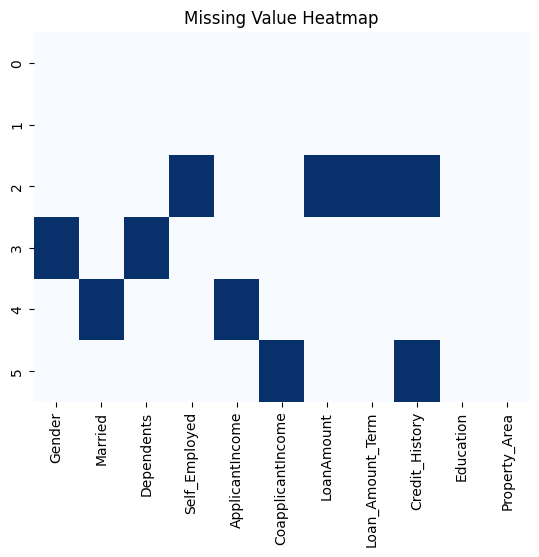


Removed 0 duplicate rows.

Cleaned Data Summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             6 non-null      object 
 1   Married            6 non-null      object 
 2   Dependents         6 non-null      int64  
 3   Self_Employed      6 non-null      object 
 4   ApplicantIncome    5 non-null      float64
 5   CoapplicantIncome  5 non-null      float64
 6   LoanAmount         6 non-null      float64
 7   Loan_Amount_Term   6 non-null      float64
 8   Credit_History     6 non-null      float64
 9   Education          6 non-null      object 
 10  Property_Area      6 non-null      object 
dtypes: float64(5), int64(1), object(5)
memory usage: 660.0+ bytes

First 5 rows after cleaning:


,Gender,Married,Dependents,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Education,Property_Area
0,Male,Yes,0,No,0.50,0.75,0.5,360.0,0.447214,Graduate,Urban
1,Female,No,1,Yes,0.00,0.00,0.0,360.0,0.447214,Not graduate,Rural
2,Male,Yes,3,No,1.00,1.00,0.3,360.0,0.447214,Graduate,Semiurban
3,Male,Yes,0,No,0.25,0.50,0.3,180.0,-2.236068,Graduate,Urban
4,Female,Yes,2,Yes,NaN,0.60,1.0,360.0,0.447214,Graduate,Rural


In [1]:
# Importing required libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, StandardScaler


# --------------------------------------------------
# 1. CREATE SAMPLE DATASET
# --------------------------------------------------

data = {
    'Gender': ['Male', 'Female', 'Male', np.nan, 'Female', 'Male'],
    'Married': ['Yes', 'No', 'Yes', 'Yes', np.nan, 'No'],
    'Dependents': ['0', '1', '3+', np.nan, '2', '0'],
    'Self_Employed': ['No', 'Yes', np.nan, 'No', 'Yes', 'No'],
    'ApplicantIncome': [5000, 3000, 7000, 4000, np.nan, 3500],
    'CoapplicantIncome': [1500, 0, 2000, 1000, 1200, np.nan],
    'LoanAmount': [200, 150, np.nan, 180, 250, 160],
    'Loan_Amount_Term': [360, 360, np.nan, 180, 360, 360],
    'Credit_History': [1, 1, np.nan, 0, 1, np.nan],
    'Education': ['Graduate', 'Not Graduate', 'Graduate', 'graduate', 'Graduate', 'Not Graduate'],
    'Property_Area': ['Urban', 'Rural', 'Semiurban', 'urban', 'Rural', 'Semiurban']
}

df = pd.DataFrame(data)

# Save as CSV (optional)
df.to_csv('/content/sample_loan_data.csv', index=False)

# Load the dataset
df = pd.read_csv('/content/sample_loan_data.csv')


# --------------------------------------------------
# 2. DISPLAY BASIC INFORMATION
# --------------------------------------------------

print("Initial Data Overview:")
df.info()


# --------------------------------------------------
# 3. HANDLING MISSING VALUES
# --------------------------------------------------

print("\nMissing Values in Each Column:")
print(df.isnull().sum())

# Missing value heatmap
sns.heatmap(df.isnull(), cbar=False, cmap="Blues")

plt.title("Missing Value Heatmap")
plt.show()


# Fill categorical missing values with mode
for col in ['Gender', 'Married', 'Dependents', 'Self_Employed']:
    df[col] = df[col].fillna(df[col].mode()[0])

# Fill numerical missing values
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())

# Fill categorical/numerical columns with mode
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(
    df['Loan_Amount_Term'].mode()[0]
)

df['Credit_History'] = df['Credit_History'].fillna(
    df['Credit_History'].mode()[0]
)


# --------------------------------------------------
# 4. REMOVING DUPLICATES
# --------------------------------------------------

initial_rows = df.shape[0]

df.drop_duplicates(inplace=True)

print(f"\nRemoved {initial_rows - df.shape[0]} duplicate rows.")


# --------------------------------------------------
# 5. DATA TYPE CONVERSION
# --------------------------------------------------

# Convert '3+' to 3
df['Dependents'] = (
    df['Dependents']
    .replace('3+', 3)
    .fillna(0)
    .astype(int)
)


# --------------------------------------------------
# 6. ENSURING CATEGORICAL CONSISTENCY
# --------------------------------------------------

for col in [
    'Gender',
    'Married',
    'Education',
    'Self_Employed',
    'Property_Area'
]:
    df[col] = df[col].str.strip().str.capitalize()


# --------------------------------------------------
# 7. NORMALIZATION
# --------------------------------------------------

min_max_scaler = MinMaxScaler()

scale_cols = [
    'ApplicantIncome',
    'CoapplicantIncome',
    'LoanAmount'
]

df[scale_cols] = min_max_scaler.fit_transform(
    df[scale_cols]
)


# Standardization
scaler = StandardScaler()

df[['Credit_History']] = scaler.fit_transform(
    df[['Credit_History']]
)


# --------------------------------------------------
# 8. FINAL OVERVIEW
# --------------------------------------------------

print("\nCleaned Data Summary:")
df.info()

print("\nFirst 5 rows after cleaning:")
display(df.head())